
# P166246 Data Management Final Report (WIP)
### Matrix number: P166246
### Name: Muzaffar Izamuddin bin Daud


###Data source is too big and is hosted in google drive in below link
###please download in order to run this .ipynb file

https://drive.google.com/drive/folders/1aO5fiudoif1c3bJO0atcvOXCllWwncHo?usp=sharing

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muzaffarizamuddin/P166246_Data_Management_Final_Report/blob/main/historical_AQI_data_combine.ipynb)

In [1]:
from pathlib import Path

for file in Path("Raw_Data_Malaysia").iterdir():
    print(file.name)


waqi-covid19-airqualitydata-2022Q1.csv
waqi-covid19-airqualitydata-2022Q2.csv
waqi-covid19-airqualitydata-2022Q3.csv
waqi-covid19-airqualitydata-2022Q4.csv
waqi-covid19-airqualitydata-2023Q1.csv
waqi-covid19-airqualitydata-2023Q2.csv
waqi-covid19-airqualitydata-2023Q3.csv
waqi-covid19-airqualitydata-2023Q4.csv
waqi-covid19-airqualitydata-2026.csv


## Combine And Clean Historical AQI Data

This step combines all CSV files from the `Raw_Data_Malaysia` folder into one dataset named `historical_AQI_data.csv`.

Cleaning actions performed:
- retain only Malaysia (`MY`) records prepared in `Raw_Data_Malaysia`
- remove metadata lines and repeated headers
- keep only the required AQI columns
- standardize text values by trimming spaces
- convert date and numeric columns into suitable data types
- remove incomplete rows and duplicate records
- sort the final dataset before saving for Hive upload


In [2]:
from pathlib import Path
import pandas as pd

raw_data_folder = Path('Raw_Data_Malaysia')
output_file = Path('historical_AQI_data_malaysia_1.csv')
csv_files = sorted(raw_data_folder.glob('*.csv'))

if not csv_files:
    raise FileNotFoundError('No CSV files were found in the Raw_Data_Malaysia folder')

dataframes = []

expected_columns = ['Date', 'Country', 'City', 'Specie', 'count', 'min', 'max', 'median', 'variance']

for file in csv_files:
    df = pd.read_csv(file, comment='#', dtype=str)
    df.columns = df.columns.str.strip()
    df = df.dropna(how='all')
    df = df[expected_columns]
    dataframes.append(df)

historical_aqi_data = pd.concat(dataframes, ignore_index=True)

# Remove repeated header rows if they appear after combining files.
historical_aqi_data = historical_aqi_data[
    historical_aqi_data['Date'].astype(str).str.strip() != 'Date'
]

# Standardize text columns.
for column in ['Country', 'City', 'Specie']:
    historical_aqi_data[column] = historical_aqi_data[column].astype(str).str.strip()

# Convert columns to suitable data types.
historical_aqi_data['Date'] = pd.to_datetime(historical_aqi_data['Date'], errors='coerce')
for column in ['count', 'min', 'max', 'median', 'variance']:
    historical_aqi_data[column] = pd.to_numeric(historical_aqi_data[column], errors='coerce')

# Remove incomplete or duplicated records.
historical_aqi_data = historical_aqi_data.dropna(subset=['Date', 'Country', 'City', 'Specie'])
historical_aqi_data = historical_aqi_data.drop_duplicates()
historical_aqi_data = historical_aqi_data.sort_values(['Date', 'Country', 'City', 'Specie']).reset_index(drop=True)
historical_aqi_data['Date'] = historical_aqi_data['Date'].dt.strftime('%Y-%m-%d')

#historical_aqi_data.to_csv(output_file, index=False) #not required as we want to combine with even more data

print(f'Combined {len(csv_files)} files into {output_file.name}')
print('Files included:')
for file in csv_files:
    print(f'- {file.name}')
print(f'Total cleaned rows: {len(historical_aqi_data):,}')
historical_aqi_data.head()


Combined 9 files into historical_AQI_data_malaysia_1.csv
Files included:
- waqi-covid19-airqualitydata-2022Q1.csv
- waqi-covid19-airqualitydata-2022Q2.csv
- waqi-covid19-airqualitydata-2022Q3.csv
- waqi-covid19-airqualitydata-2022Q4.csv
- waqi-covid19-airqualitydata-2023Q1.csv
- waqi-covid19-airqualitydata-2023Q2.csv
- waqi-covid19-airqualitydata-2023Q3.csv
- waqi-covid19-airqualitydata-2023Q4.csv
- waqi-covid19-airqualitydata-2026.csv
Total cleaned rows: 114,218


,Date,Country,City,Specie,count,min,max,median,variance
0,2022-03-28,MY,Alor Setar,aqi,42,32.0,47.0,37.0,205.60
1,2022-03-28,MY,Alor Setar,dew,42,24.0,27.0,25.0,8.08
2,2022-03-28,MY,Alor Setar,humidity,48,66.0,100.0,88.0,1074.26
3,2022-03-28,MY,Alor Setar,pressure,48,1006.0,1012.0,1010.0,31.47
4,2022-03-28,MY,Alor Setar,temperature,48,25.0,33.0,27.0,78.87


In [3]:
historical_aqi_data.City.value_counts()

City
Malacca         9589
Kuala Lumpur    9357
Klang           9310
Alor Setar      8929
Kuantan         8746
Kota Bharu      8713
George Town     8623
Kuching         8554
Johor Bahru     8547
Seremban        8528
Taiping         8448
Ipoh            8441
Miri            8433
Name: count, dtype: int64

In [4]:
historical_aqi_data.Specie.value_counts()


Specie
humidity         17108
pressure         17108
temperature      17108
wind-speed       17108
dew              17102
aqi              15897
wind-gust         4698
pm10              1248
pm25              1248
no2               1244
so2               1244
co                1243
o3                1243
precipitation      619
Name: count, dtype: int64

In [5]:

# Need to run previous cell
base_data = historical_aqi_data.copy()


raw_data_folder_2 = Path('Raw_Data_Malaysia_2')
output_file = Path('Malaysia_AQI_data_combined.csv')
csv_files_2 = sorted(raw_data_folder_2.glob('*.csv'))

if not csv_files_2:
    raise FileNotFoundError('No CSV files were found in Raw_Data_Malaysia_2')

expected_base_columns = ['Date', 'Country', 'City', 'Specie', 'count', 'min', 'max', 'median', 'variance']
base_data.columns = base_data.columns.str.strip()
base_data = base_data[expected_base_columns].copy()

def city_from_filename(file_path: Path) -> str:
    name = file_path.stem.replace('-air-quality', '').strip()
    city = name.split(',')[0].strip(' -')
    return city.title()

extra_frames = []
for file in csv_files_2:
    df = pd.read_csv(file)
    df.columns = df.columns.str.strip().str.lower()

    if 'date' not in df.columns:
        continue

    pollutant_columns = [c for c in df.columns if c not in ['date']]
    melted = df.melt(id_vars='date', value_vars=pollutant_columns, var_name='Specie', value_name='value')

    melted['Date'] = pd.to_datetime(melted['date'], errors='coerce')
    melted['value'] = pd.to_numeric(melted['value'], errors='coerce')
    melted = melted.dropna(subset=['Date', 'value'])

    if melted.empty:
        continue

    city_name = city_from_filename(file)
    transformed = pd.DataFrame({
        'Date': melted['Date'],
        'Country': 'Malaysia',
        'City': city_name,
        'Specie': melted['Specie'].astype(str).str.strip().str.lower(),
        'count': 1,
        'min': melted['value'],
        'max': melted['value'],
        'median': melted['value'],
        'variance': 0
    })
    extra_frames.append(transformed)

if not extra_frames:
    raise ValueError('Raw_Data_Malaysia_2 files were read, but no valid rows were produced.')

extra_data = pd.concat(extra_frames, ignore_index=True)
combined_data = pd.concat([base_data, extra_data], ignore_index=True)

for column in ['Country', 'City', 'Specie']:
    combined_data[column] = combined_data[column].astype(str).str.strip()

combined_data['Date'] = pd.to_datetime(combined_data['Date'], errors='coerce')
for column in ['count', 'min', 'max', 'median', 'variance']:
    combined_data[column] = pd.to_numeric(combined_data[column], errors='coerce')

combined_data = combined_data.dropna(subset=['Date', 'Country', 'City', 'Specie'])
combined_data = combined_data.drop_duplicates()
combined_data = combined_data.sort_values(['Date', 'Country', 'City', 'Specie']).reset_index(drop=True)
combined_data['Date'] = combined_data['Date'].dt.strftime('%Y-%m-%d')

combined_data.to_csv(output_file, index=False, header=False)

print(f'Added city files: {len(csv_files_2)}')
print(f'Rows from Raw_Data_Malaysia_2: {len(extra_data):,}')
print(f'Total rows in combined file: {len(combined_data):,}')
print(f'Output: {output_file.name}')
combined_data.head()


Added city files: 5
Rows from Raw_Data_Malaysia_2: 19,832
Total rows in combined file: 134,050
Output: Malaysia_AQI_data_combined.csv


,Date,Country,City,Specie,count,min,max,median,variance
0,2014-01-01,Malaysia,Banting,aqi,1,41.0,41.0,41.0,0.0
1,2014-01-01,Malaysia,Cheras,aqi,1,32.0,32.0,32.0,0.0
2,2014-01-01,Malaysia,Petaling-Jaya,aqi,1,40.0,40.0,40.0,0.0
3,2014-01-01,Malaysia,Shah-Alam,aqi,1,53.0,53.0,53.0,0.0
4,2014-01-02,Malaysia,Banting,aqi,1,39.0,39.0,39.0,0.0


In [ ]:
# Direct link to your data on GitHub. RUN THIS CELL IF SKIPPING THE ABOVE DATA LOAD AND COMBINE CELLS ABOVE
data_url = 'https://raw.githubusercontent.com/muzaffarizamuddin/P166246_Data_Management_Final_Report/main/Malaysia_AQI_data_combined.csv'
df = pd.read_csv(data_url)

In [ ]:
#use pivot table to check available dates for pm25,pm10, no2 and co (major pollutants)
combined_data['Date'] = pd.to_datetime(combined_data['Date'])

date_range_pivot = combined_data.pivot_table(
    index=['City', 'Specie'], 
    values='Date', 
    aggfunc=['min', 'max']
)
date_range_pivot.columns = ['Start Date', 'End Date']
target_species = ['pm25', 'pm10', 'no2', 'co']
filtered_pivot = date_range_pivot.query("Specie in @target_species")

# ensure display does not truncate the output
pd.set_option('display.max_rows', None)

print(filtered_pivot)

                     Start Date   End Date
City          Specie                      
Alor Setar    co     2025-07-28 2025-10-31
              no2    2025-07-28 2025-10-31
              pm10   2025-07-28 2025-10-31
              pm25   2025-07-28 2025-10-31
Banting       no2    2025-07-27 2025-10-30
              pm10   2025-07-27 2025-10-30
              pm25   2025-07-28 2025-10-31
Cheras        no2    2025-07-27 2025-10-30
              pm10   2025-07-27 2025-10-30
              pm25   2025-07-28 2025-10-31
George Town   co     2025-07-28 2025-10-31
              no2    2025-07-28 2025-10-31
              pm10   2025-07-28 2025-10-31
              pm25   2025-07-28 2025-10-31
Ipoh          co     2025-07-28 2025-10-31
              no2    2025-07-28 2025-10-31
              pm10   2025-07-28 2025-10-31
              pm25   2025-07-28 2025-10-31
Johor Bahru   co     2025-07-28 2025-10-31
              no2    2025-07-28 2025-10-31
              pm10   2025-07-28 2025-10-31
           

In [7]:
combined_data.Specie.value_counts()

Specie
aqi              33694
humidity         17108
pressure         17108
temperature      17108
wind-speed       17108
dew              17102
wind-gust         4698
pm10              1728
pm25              1728
no2               1724
o3                1723
so2               1359
co                1243
precipitation      619
Name: count, dtype: int64

In [8]:
combined_data.isnull().sum()

Date        0
Country     0
City        0
Specie      0
count       0
min         0
max         0
median      0
variance    0
dtype: int64

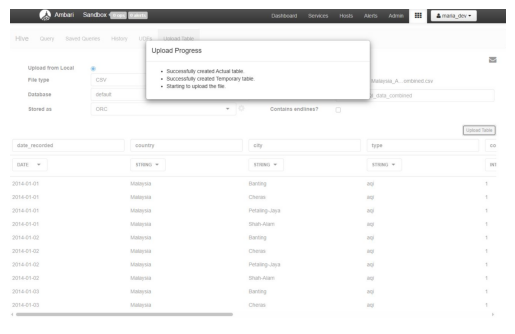

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

path = "images/upload_table.JPG"

# Read and display
img = mpimg.imread(path)
plt.imshow(img)
plt.axis('off') # Hide the X and Y axes
plt.show()

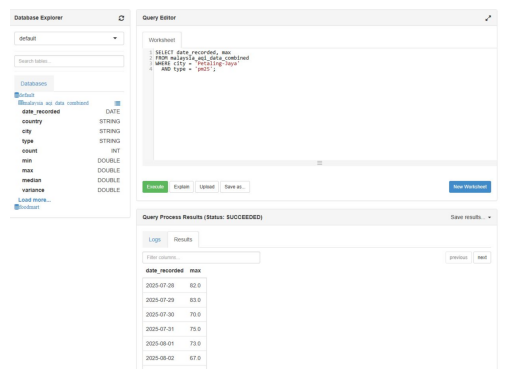

In [10]:
path = "images/pm25_petaling_jaya.JPG"

# Read and display
img = mpimg.imread(path)
plt.imshow(img)
plt.axis('off') # Hide the X and Y axes
plt.show()

##Pig Script filter_pm25.pig i executed inside Ambari at this stage

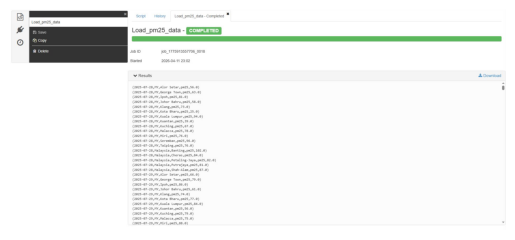

In [11]:
path = "images/pig_success.JPG"

# Read and display
img = mpimg.imread(path)
plt.imshow(img)
plt.axis('off') # Hide the X and Y axes
plt.show()

In [12]:
# Define the column names since Pig output didnt include header
column_names = ['date_recorded', 'country', 'city', 'type', 'median']

# Read the CSV
df = pd.read_csv('pm25_only_pigoutput.csv', names=column_names)

# Display the filtered file that uses Pig to Filter
df.head()

,date_recorded,country,city,type,median
0,2025-07-28,MY,Alor Setar,pm25,56.0
1,2025-07-28,MY,George Town,pm25,63.0
2,2025-07-28,MY,Ipoh,pm25,81.0
3,2025-07-28,MY,Johor Bahru,pm25,58.0
4,2025-07-28,MY,Klang,pm25,73.0


In [ ]:
#use plotly for interactive plot since many data is plotted at once
import plotly.express as px

fig = px.line(df, 
              x="date_recorded", 
              y="median", 
              color="city",
              title="PM2.5 Levels by City: July - Oct 2025",
              labels={"median": "PM2.5 Concentration", "date_recorded": "Date"})

fig.update_layout(hovermode="x unified") # Shows all values for a date when hovering
fig.show()

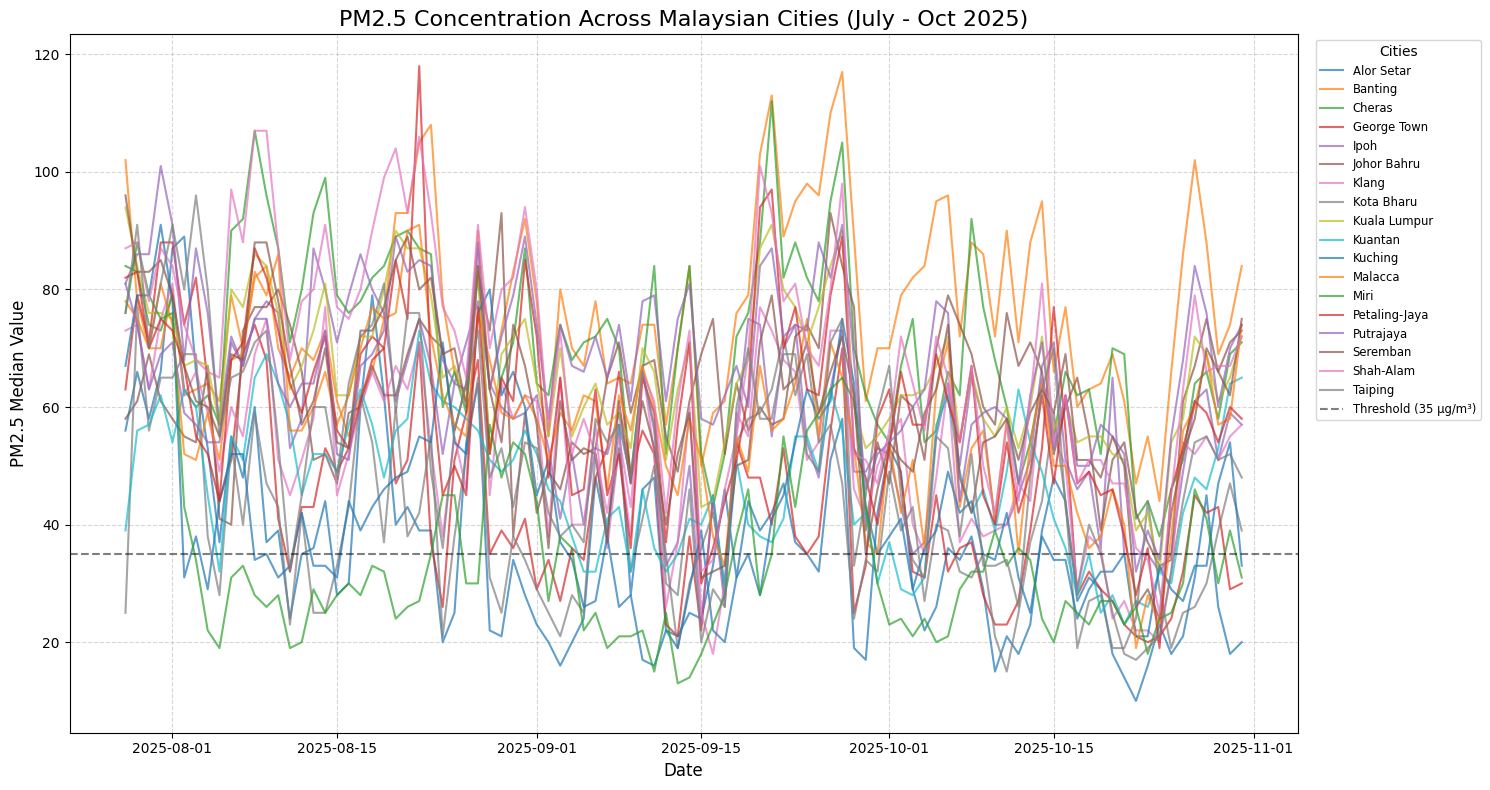

In [ ]:
#matplotlib version plotting
# 1. Prepare data
df['date_recorded'] = pd.to_datetime(df['date_recorded'])
df = df.sort_values(['city', 'date_recorded'])

# 2. Setup the plot
plt.figure(figsize=(15, 8))

# 3. Plot each city
for city in df['city'].unique():
    city_data = df[df['city'] == city]
    plt.plot(city_data['date_recorded'], 
             city_data['median'], 
             label=city, 
             linewidth=1.5, 
             alpha=0.7)

# 4. Add a horizontal line for the WHO / Malaysian API 'Unhealthy' threshold 
# PM2.5 threshold for 'Unhealthy' is often cited around 35-55 µg/m³ depending on the standard
plt.axhline(y=35, color='black', linestyle='--', alpha=0.5, label='Threshold (35 µg/m³)')

# 5. Labels and Styling
plt.title('PM2.5 Concentration Across Malaysian Cities (July - Oct 2025)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('PM2.5 Median Value', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Move legend outside the plot
plt.legend(title="Cities", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize='small', ncol=1)

plt.tight_layout()
plt.show()